In [1]:
from pathlib import Path
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

In [2]:
def plot_metrics(paths, keys=["train/loss"]):
    if not isinstance(paths, dict):
        paths = {"0": paths}

    eas = {}
    for name, path in paths.items():
        ea = event_accumulator.EventAccumulator(path)
        ea.Reload()
        eas[name] = ea

    n = len(keys)
    cols = 2
    rows = (n + 1) // 2

    fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    for i, key in enumerate(keys):
        for name, ea in eas.items():
            scalars = ea.Scalars(key)
            steps = [x.step for x in scalars]
            values = [x.value for x in scalars]

            axes[i].plot(steps, values, label=f"{name}[{key}]")
            axes[i].set_xlabel('Step')
            axes[i].set_ylabel('Value')
            axes[i].set_title(key)
            axes[i].legend()
            axes[i].grid(True)

    # Скрываем лишние ячейки, если ключей нечётное количество
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

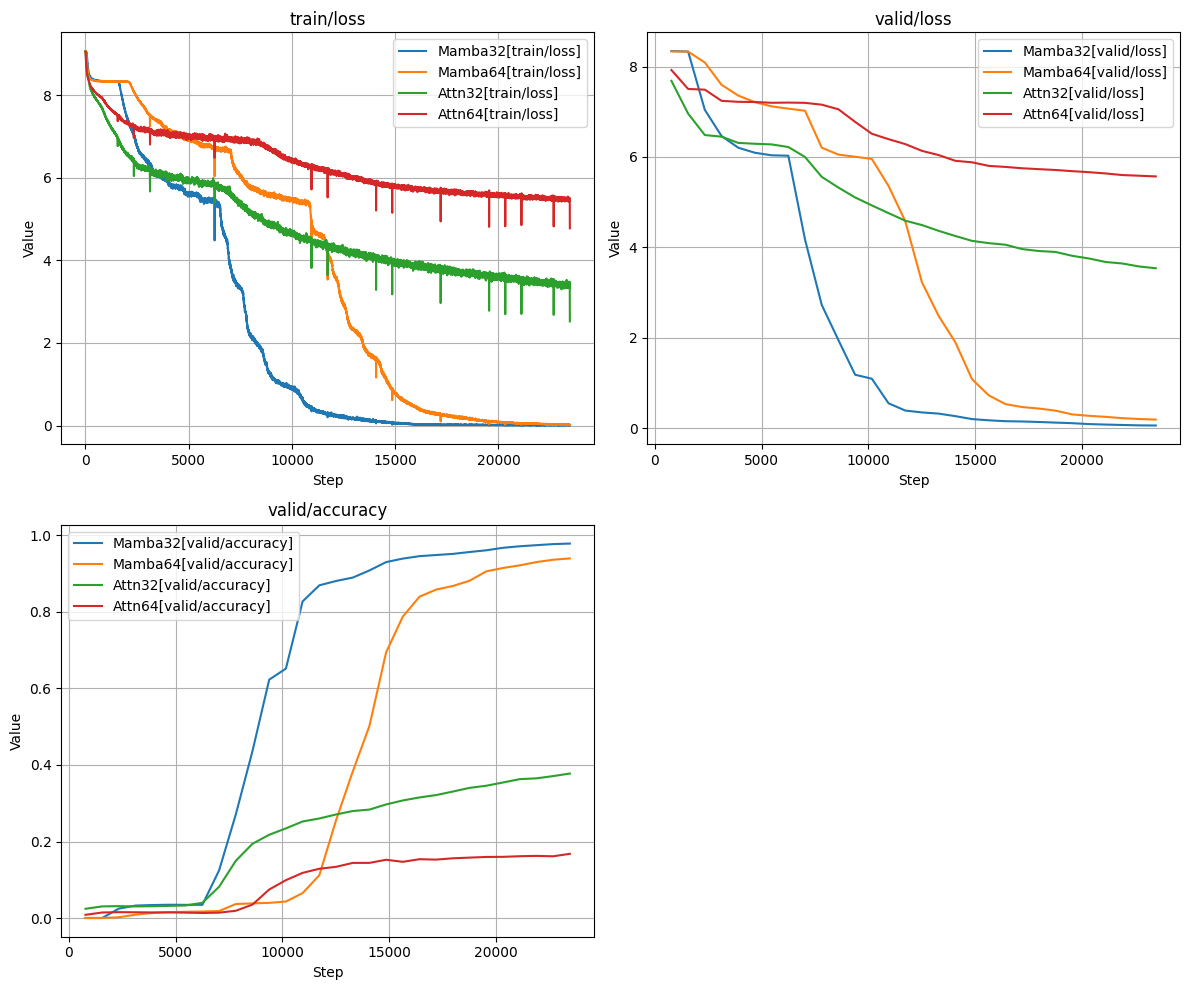

In [4]:
plot_metrics(
    {
        "Mamba32": "/home/needpetrov/projects/zoology/runs/Mamba_2_layers__lr_0.0003__difficulty_32/default/events.out.tfevents.1777909991.butch.38525.0",
        "Mamba64": "/home/needpetrov/projects/zoology/runs/Mamba_2_layers__lr_0.0003__difficulty_64/default/events.out.tfevents.1777915111.butch.65246.0",
        "Attn32": "/home/needpetrov/projects/zoology/runs/MHA_h4_2_layers__lr_0.0003__difficulty_32/default/events.out.tfevents.1777915105.butch.65084.0",
        "Attn64": "/home/needpetrov/projects/zoology/runs/MHA_h4_2_layers__lr_0.0003__difficulty_64/default/events.out.tfevents.1777909986.butch.38386.0",
    },
    keys=["train/loss", "valid/loss", "valid/accuracy"],
)